# All computations

In [1]:
import numpy as np
import pandas as pd
import os

## Dataframe computations

In [ ]:
from surface_functions import compute_surface_variance, compute_surface_roughness, compute_height_height_correlations
from surface_functions import compute_structure_factor, compute_phase_covariance

### 2. Roughness

In [ ]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        # # Restrict the computation to data of a given length
        # if typenoise == "Columnar":
        #     new_df = df[~(df["phases"].apply(lambda arr: arr.shape[0] == 27))]

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [ ]:
# Note: we start from scratch the average DataFrame (each time this script is run)
avg_df = pd.DataFrame()
avg_df_path = "AverageSims.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print("Saved AverageSims to:", avg_df_path)

Saved AverageSims to: AverageSims.pkl


In [ ]:
avg_df[(avg_df["K"] == 20) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight
avg_id,,,,,,,,,,,
Columnar_delta0_L125_K20.0_T20000_M200,Columnar,0.000000,0,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",200,20000,"[0.0, 0.14211780522175843, 0.19700187898423172...","[0.0, 0.14491166998027283, 0.20194255816037937...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L250_K20.0_T20000_M457,Columnar,0.000000,0,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",457,20000,"[0.0, 0.14726257028696876, 0.206085076909872, ...","[0.0, 0.14852566605196862, 0.2083641682374369,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L500_K20.0_T20000_M430,Columnar,0.000000,0,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",430,20000,"[0.0, 0.15117305657918037, 0.21282600391954395...","[0.0, 0.15184674700609221, 0.21403775150603213...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L1000_K20.0_T20000_M505,Columnar,0.000000,0,20.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",505,20000,"[0.0, 0.1521718275463539, 0.2149099616368219, ...","[0.0, 0.1524993882938343, 0.2155149673633728, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L125_K20.0_T20000_M444,Columnar,1.373401,atan5,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",444,20000,"[0.0, 0.22292159456595645, 0.3054045323983475,...","[0.0, 0.2246243048194169, 0.3084011109842398, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L250_K20.0_T20000_M468,Columnar,1.373401,atan5,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",468,20000,"[0.0, 0.22738818294732252, 0.31273919165137265...","[0.0, 0.22823772573209508, 0.31427011004782035...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L500_K20.0_T20000_M356,Columnar,1.373401,atan5,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",356,20000,"[0.0, 0.23001848117225157, 0.3171881836918727,...","[0.0, 0.23038390187674862, 0.31788337331380656...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L1000_K20.0_T20000_M262,Columnar,1.373401,atan5,20.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",262,20000,"[0.0, 0.23048765247510317, 0.31842345757759766...","[0.0, 0.23067580249951875, 0.3187661700488755,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


### 3. Height-height correlations (takes the longest)

In [ ]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            heightheight = np.asarray(compute_height_height_correlations(phases), dtype=float)

            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [ ]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

### 4. Structure Factor

In [ ]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        structurefactor_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            structurefactor = np.asarray(compute_structure_factor(phases), dtype=float)

            structurefactor_list.append(structurefactor)

        # Avoid chained-assignment issues
        df = df.copy()
        df["structurefactor"] = structurefactor_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE STRUCTURE FACTOR PER (K, L, T) ##
        # group by K, L, T and compute mean structure factor for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            structurefactor_arrays = [np.asarray(r, dtype=float) for r in group["structurefactor"]]
            mean_structurefactor = np.mean(np.stack(structurefactor_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_structurefactor": mean_structurefactor,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [ ]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_structurefactor"] = new_avg["mean_structurefactor"]

avg_df.to_pickle(avg_df_path)

### 5. Phase covariance (takes long as well)

In [ ]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        phasecovariance_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            phasecovariance = np.asarray(compute_phase_covariance(phases), dtype=float)

            phasecovariance_list.append(phasecovariance)

        # Avoid chained-assignment issues
        df = df.copy()
        df["phasecovariance"] = phasecovariance_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            phasecovariance_arrays = [np.asarray(r, dtype=float) for r in group["phasecovariance"]]
            mean_phasecovariance = np.mean(np.stack(phasecovariance_arrays, axis=0), axis=0)

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [ ]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

### 6. Phase fluctuations

## Inspection of the computed quantities

In [2]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

from plotting_helpers import plot_roughness_evolution, plot_roughness_collapse, plot_heightdifference_evolution, plot_heightdifference_collapse
from plotting_helpers import plot_structurefactor_evolution, plot_structurefactor_collapse

In [3]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [4]:
T = 20000
L = 500

In [5]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND)
tx = {"TimeDep": {"EW": 1/30, "KPZ": 1/3}, "Columnar": {"EW": 1/200, "KPZ": 1/10}}

### 2. Roughness

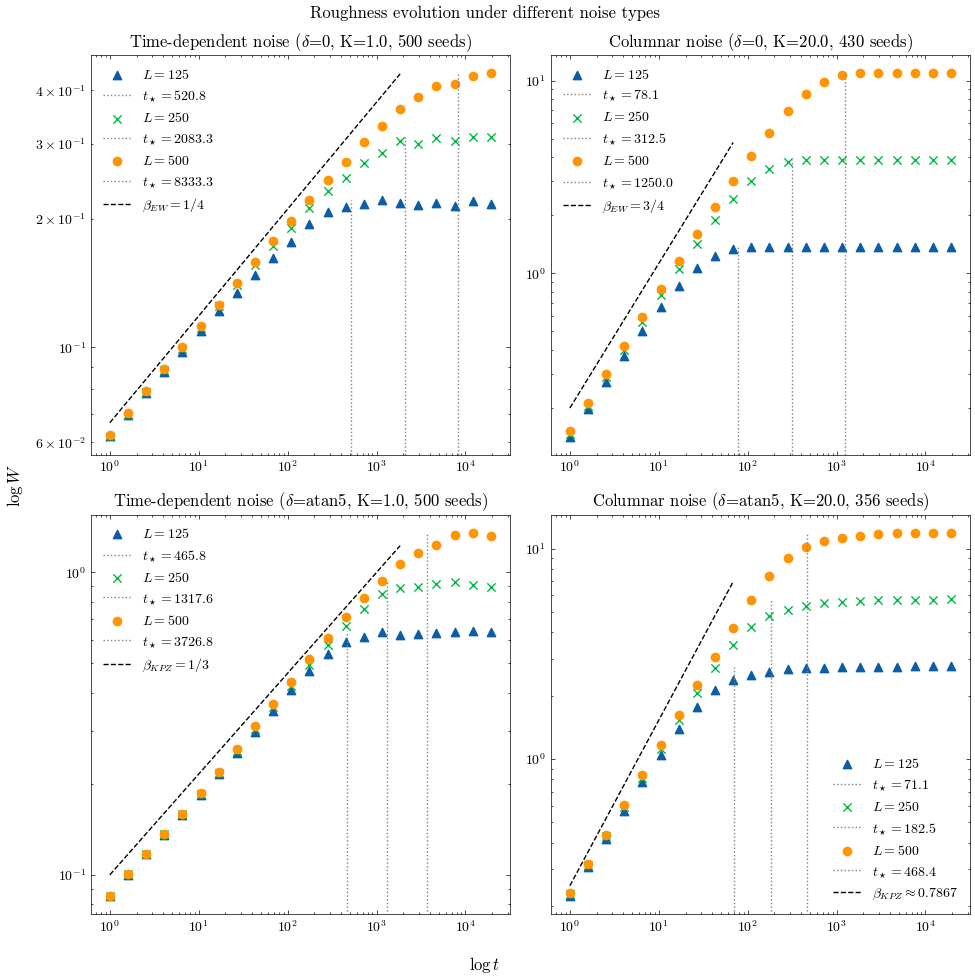

In [6]:
plot_roughness_evolution(avg_df, T, tx)

#### Family-Vicsek collapse

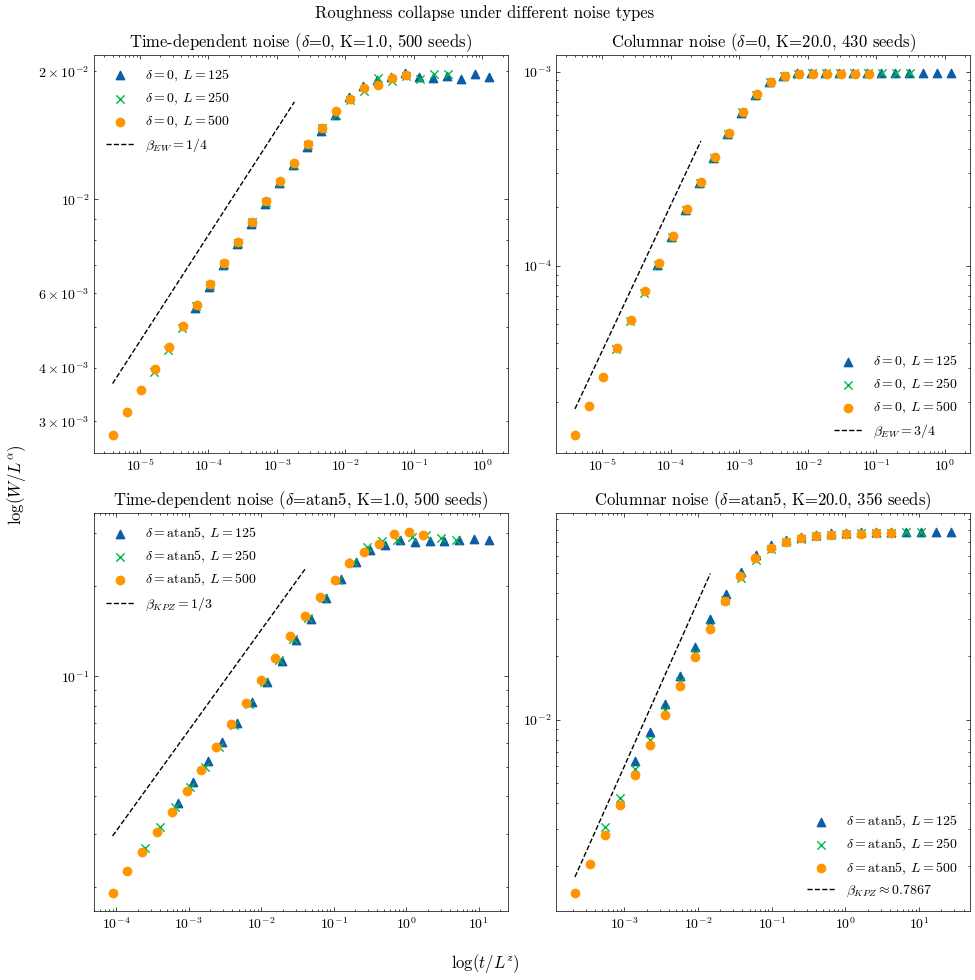

In [7]:
plot_roughness_collapse(avg_df, T)

### 3. Height-difference correlations

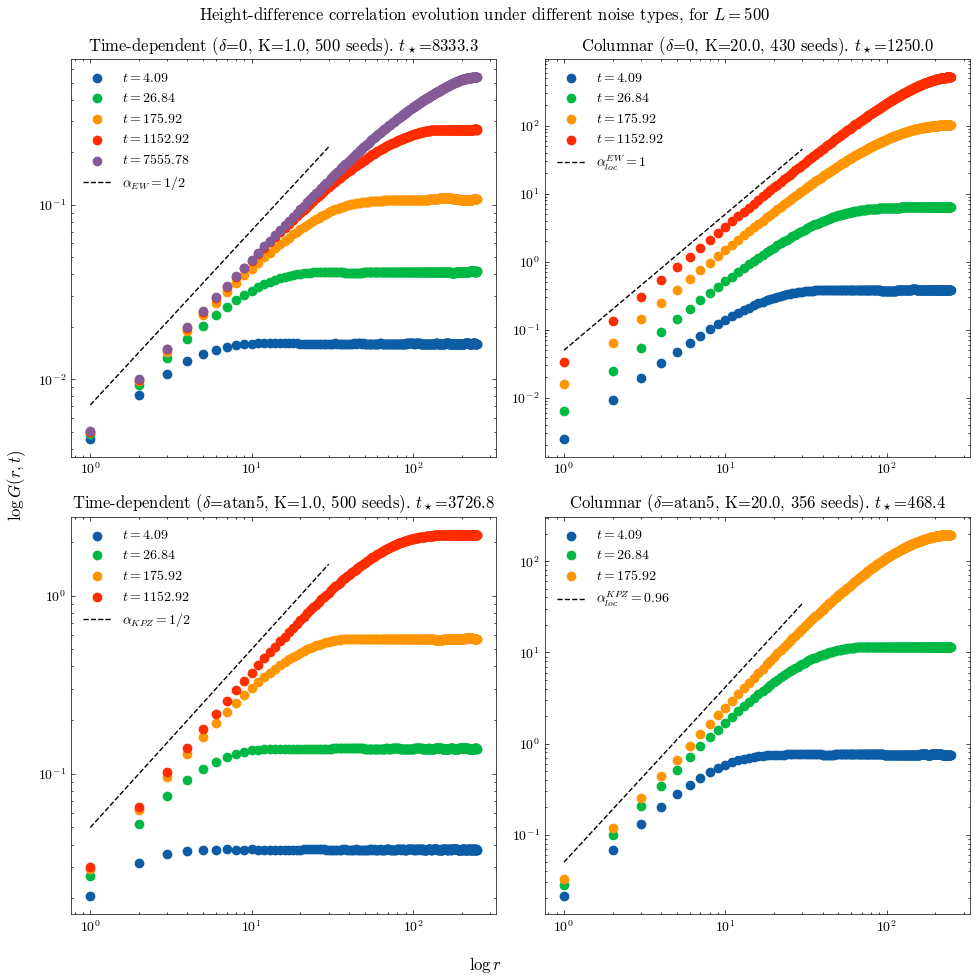

In [8]:
plot_heightdifference_evolution(avg_df, L, T, tx)

#### Family-Vicsek collapse

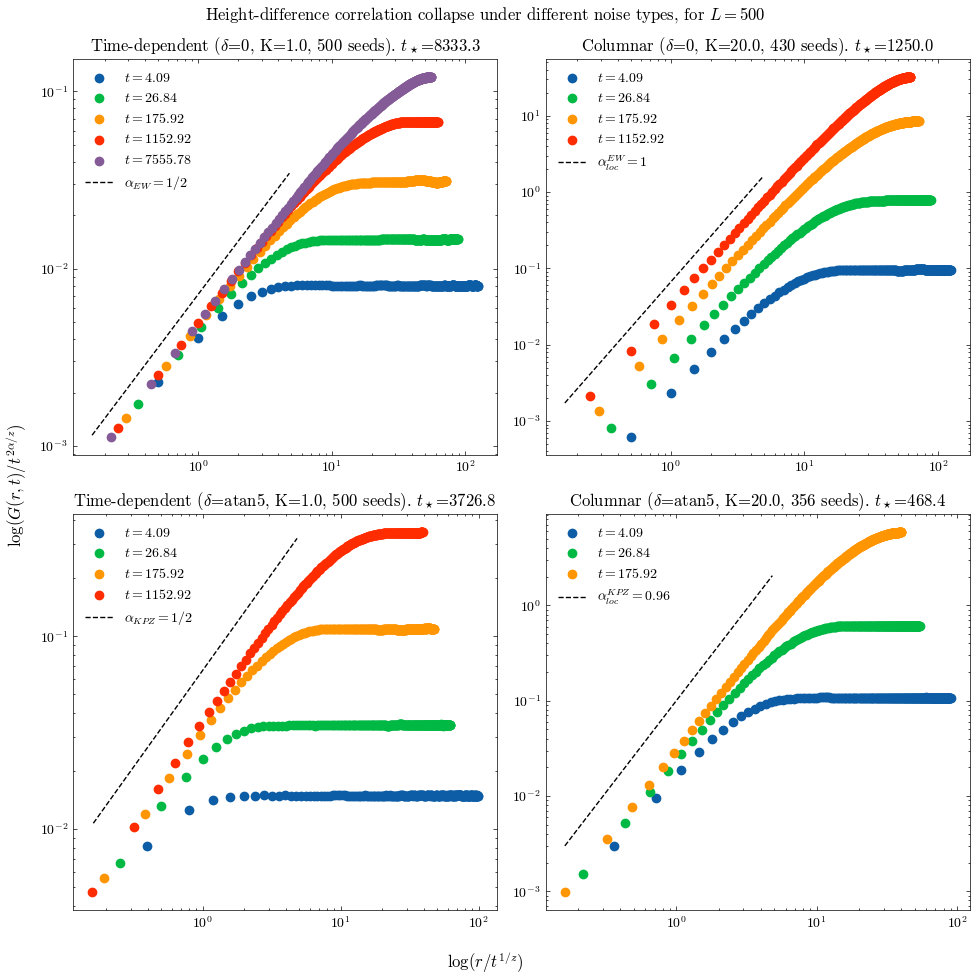

In [10]:
plot_heightdifference_collapse(avg_df, L, T, tx)

### 4. Structure factor

/home/gonzalo/Pruebas/RoughKuramoto/plotting_helpers.py:348: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,0].set_ylim(0,1e3)
/home/gonzalo/Pruebas/RoughKuramoto/plotting_helpers.py:349: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,1].set_ylim(0,1e5)


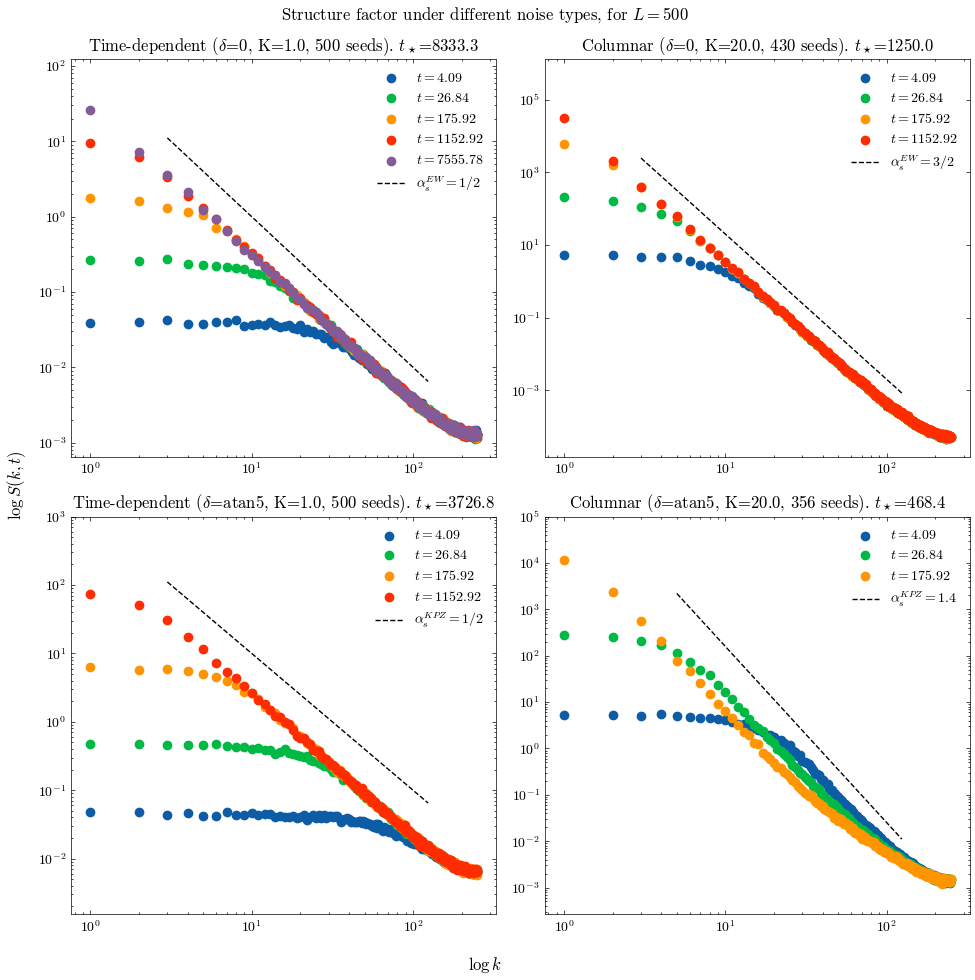

In [12]:
plot_structurefactor_evolution(avg_df, L, T, tx)

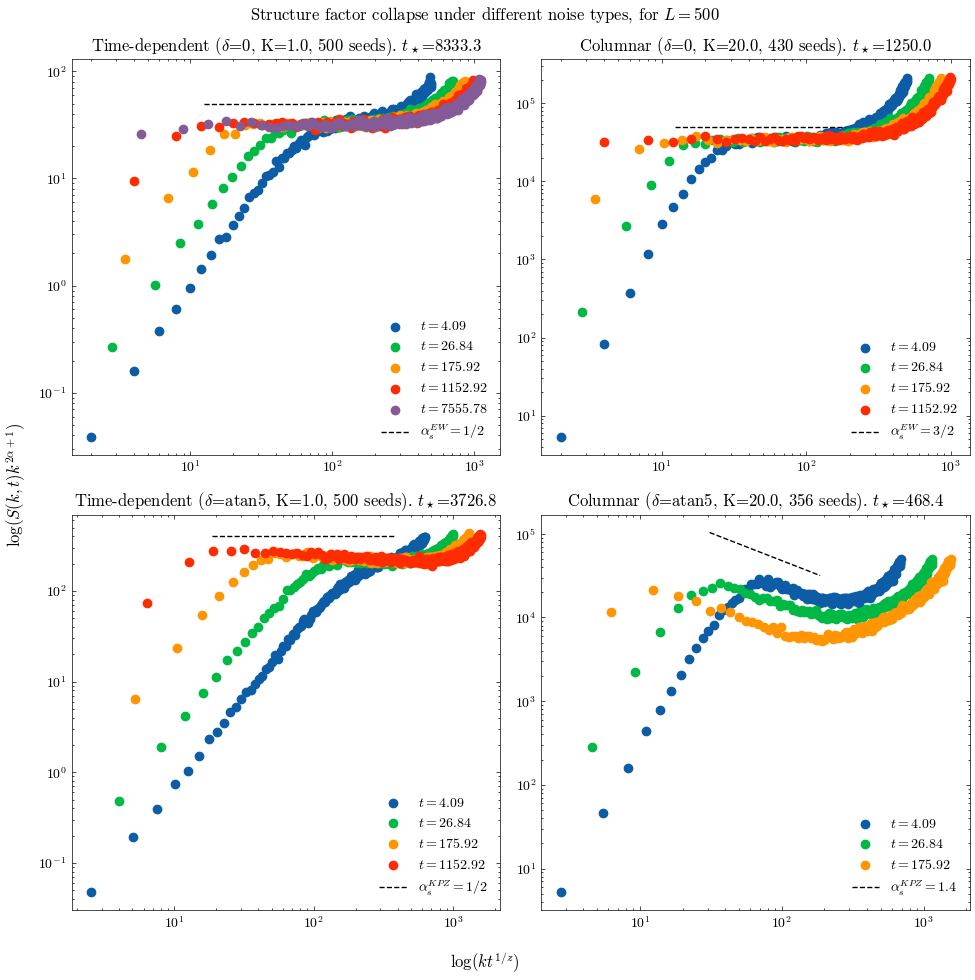

In [11]:
plot_structurefactor_collapse(avg_df, L, T, tx)

### 5. Phase covariance

### 6. Phase fluctuations